#Análisis exploratorio de Datos

Luis Enrique Ceballos Alexander

A01754326

##Explorando el Titanic

El hundimiento del Titanic ha sido uno de los eventos mas importantes y relevantes de la historia, no solo por la tragedia que fue, si no por todo lo que implica por detrás, con su pelicula e investigaciones vemos que se habla de cosas más profundas como la desigualdad social, decisiones humanas bajo presión, acceso a recursos, etc.

Con este dataset podremos analizar variables como la edad, sexo, información económicas y así analizar patrones asociados con la supervivencia.

Mi objetivo es ver mas allá de solo sacar las gráficas a contestar a preguntas interesantes que nos puedan ayudar a entender como en verdad afectaba cada variable la supervivencia de los diferentes grupos de personas.

##Dataset "Titanic"

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

titanic = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")

titanic.head(16)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


###Parte 1: Variación (¿Cómo varían mis datos?)

Trabajaré con estas dos variables:
- **Sipsb**: Número de hermanos/esposos
- **Pclass**: Clase social: 1 = alta, 2 = media, 3 = baja

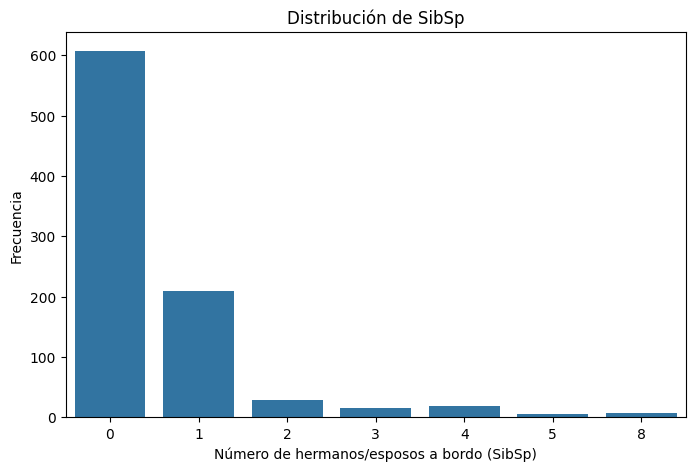

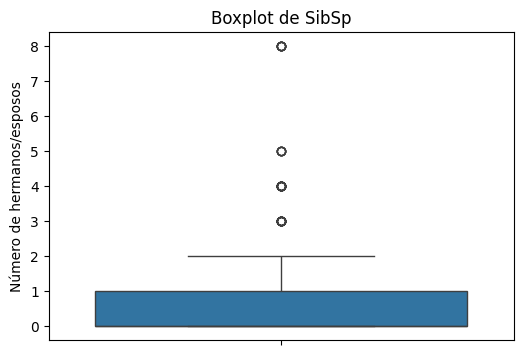

,count
SibSp,
0,608
1,209
2,28
3,16
4,18
5,5
8,7


In [ ]:
#Visualización "SibSp"

plt.figure(figsize=(8,5))
sns.countplot(data=titanic, x="SibSp")
plt.title("Distribución de SibSp")
plt.xlabel("Número de hermanos/esposos a bordo (SibSp)")
plt.ylabel("Frecuencia")
plt.show()


plt.figure(figsize=(6,4))
sns.boxplot(y=titanic["SibSp"])
plt.title("Boxplot de SibSp")
plt.ylabel("Número de hermanos/esposos")
plt.show()

titanic["SibSp"].value_counts().sort_index()

###Observaciones de SibSp

- La mayoría de pasajeros tiene SibSp = 0 o sea que viajan sin pareja/hermanos.

- El siguiente valor más común suele ser 1.

- Valores como 3, 4, 5, 8 son valores inusuales.

- El valor 8 casi seguro aparece como outlier claro.


### Hipótesis

- Mucha gente viajaba sola ya sea por viajes de trabajo o por la migración que se saba tanto en esa época.



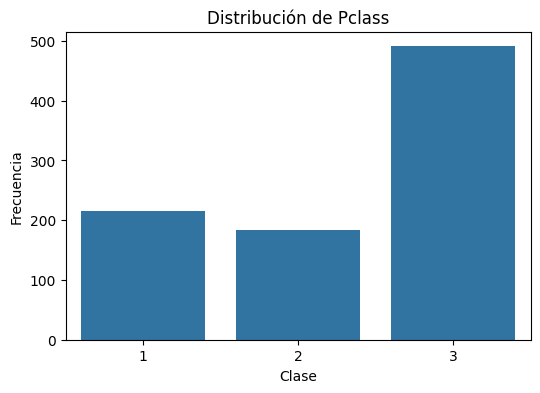

,count
Pclass,
3,491
1,216
2,184


In [ ]:
#Visualización "Pclass"

plt.figure(figsize=(6,4))
sns.countplot(data=titanic, x="Pclass")
plt.title("Distribución de Pclass")
plt.xlabel("Clase")
plt.ylabel("Frecuencia")
plt.show()

titanic["Pclass"].value_counts()

###Observaciones de Pclass

- Hay más pasajeros en tercera clase (3) que en primera o segunda.

- Primera clase (1) es la menos frecuente (mas cara).


### Hipótesis

- El Titaic en su mayoría transportaba inmigrantes y gente de la tercera clase, hay pocos de primera y segunda por que había muy poca gente con ese poder adquisitivo.

###Parte 2: Covariación (¿Cómo se relacionan las variables?)

**Relación 1**

Pregunta específica
- ¿El número de hermanos/esposos a bordo (SibSp) varía según la clase social (Pclass)?

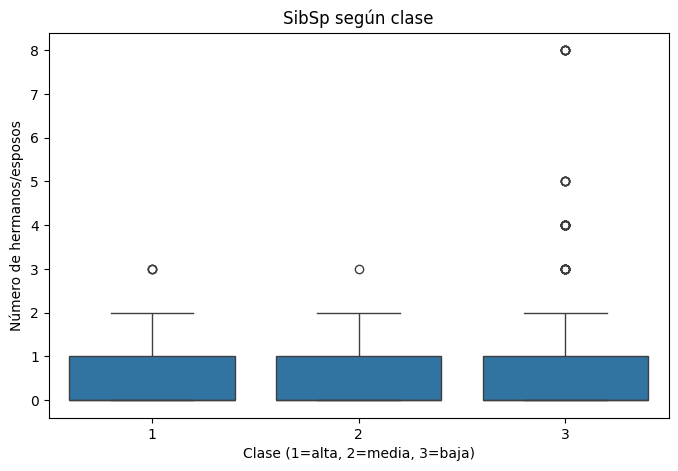

,SibSp
Pclass,
1,0.416667
2,0.402174
3,0.615071


In [ ]:
#Visualización

plt.figure(figsize=(8,5))
sns.boxplot(data=titanic, x="Pclass", y="SibSp")
plt.title("SibSp según clase")
plt.xlabel("Clase (1=alta, 2=media, 3=baja)")
plt.ylabel("Número de hermanos/esposos")
plt.show()

titanic.groupby("Pclass")["SibSp"].mean()


###Interpretación
- Se observa mayor dispersión de SibSp en tercera clase.

- Los valores más altos (familias numerosas) aparecen más en clase 3.

- Primera clase muestra menor variabilidad.

###Conexión histórica:
La tercera clase incluía muchas familias migrantes, lo que explicaría mayor número de hermanos/esposos viajando juntos. En primera clase predominaban más viajes individuales o en pareja.

**Relación 2**

Pregunta específica:
- ¿La supervivencia (Survived) cambia según la combinación de clase social (Pclass) y número de hermanos/esposos (SibSp)?

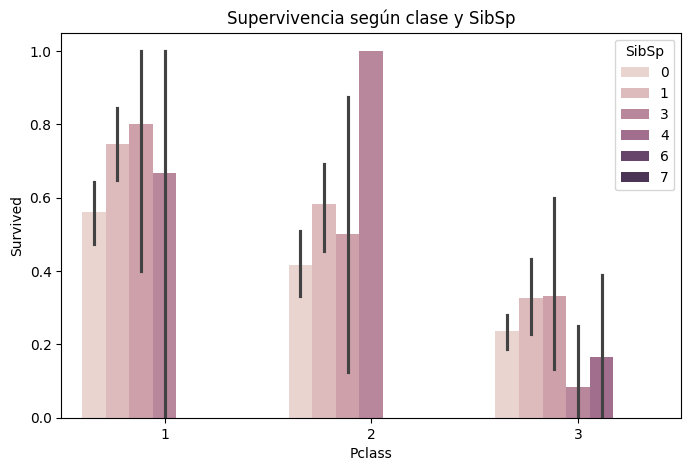

Pclass  SibSp
1       0        0.562044
        1        0.746479
        2        0.800000
        3        0.666667
2       0        0.416667
        1        0.581818
        2        0.500000
        3        1.000000
3       0        0.236467
        1        0.325301
        2        0.333333
        3        0.083333
        4        0.166667
        5        0.000000
        8        0.000000
Name: Survived, dtype: float64

In [ ]:
#Visualización

plt.figure(figsize=(8,5))
sns.barplot(data=titanic, x="Pclass", y="Survived", hue="SibSp")
plt.title("Supervivencia según clase y SibSp")
plt.show()

titanic.groupby(["Pclass", "SibSp"])["Survived"].mean()


###Interpretación
- En primera clase, incluso pasajeros con SibSp = 0 pueden tener alta supervivencia mientras que en tercera clase, la supervivencia suele disminuir, especialmente con valores altos de SibSp.

###Conexión histórica:

- No solo la clase importaba, sino también la logística familiar. Evacuar con muchos dependientes en tercera clase pudo haber sido más difícil debido a ubicación y acceso a botes.

**Relación 3**

Pregunta específica:
- ¿La relación entre clase social (Pclass) y tamaño familiar (SibSp) cambia según el puerto de embarque (Embarked)?

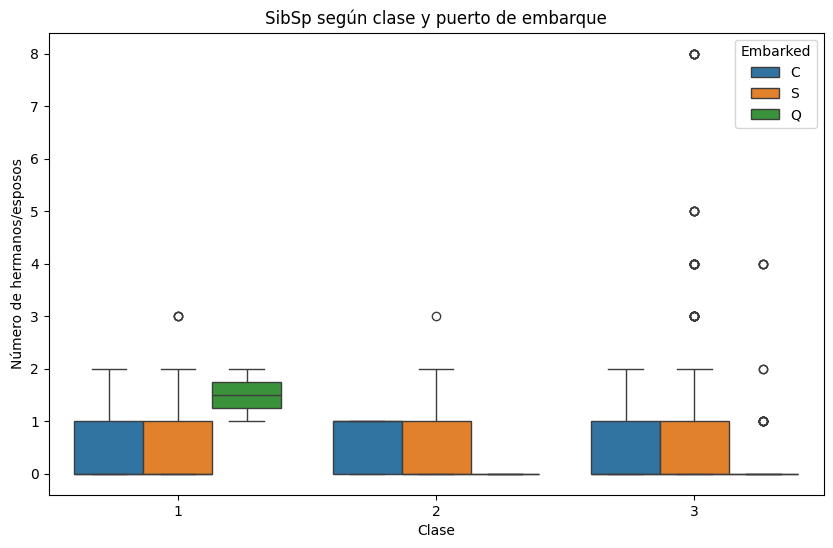

In [ ]:
#Visualización

plt.figure(figsize=(10,6))
sns.boxplot(data=titanic, x="Pclass", y="SibSp", hue="Embarked")
plt.title("SibSp según clase y puerto de embarque")
plt.xlabel("Clase")
plt.ylabel("Número de hermanos/esposos")
plt.show()


###Interpretación
- La tercera clase concentra tanto más variabilidad como los valores más extremos.

El puerto de embarque también influye:

- Queenstown (Q) parece tener mayor concentración de familias en clase baja.

- Cherbourg (C) muestra más viajes pequeños.

###Conexión histórica:

- Queenstown (Irlanda) era punto fuerte de migración hacia EE.UU y vemos que la tercera clase transportaba familias completas emigrando.

- Primera clase era más individualista y económicamente privilegiada.

- Las familias numerosas eran más comunes en sectores socioeconómicos bajos en 1912.

###Parte 3. Valores faltantes

In [ ]:
#Valores faltantes
titanic.isnull().sum()


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


<Axes: >

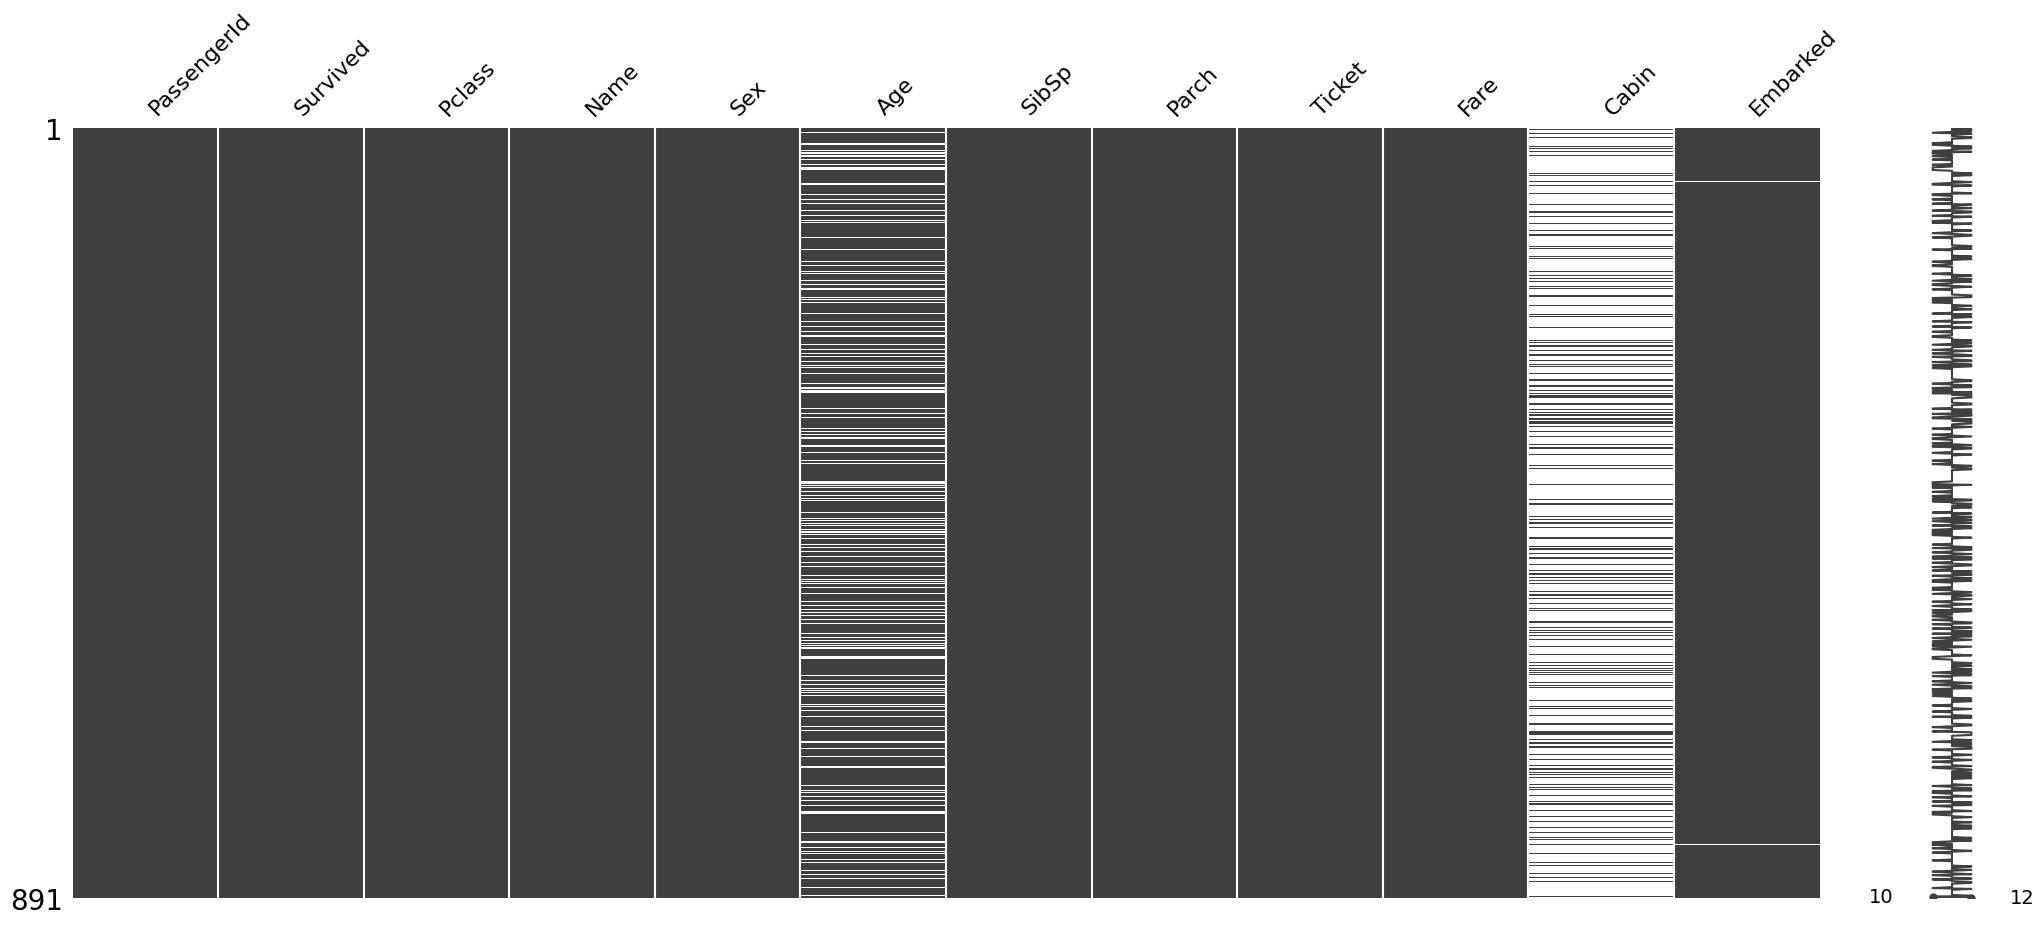

In [ ]:
# Visualizar patrón de valores faltantes
import missingno as msno  # pip install missingno
msno.matrix(titanic)

##Preguntas

¿Qué variables tienen valores faltantes?
- Age, Cabin y Embarked

¿Los valores faltantes son aleatorios o siguen un patrón? (ej: ¿la edad faltante está relacionada con la clase del pasajero?)
- Los valores faltante podrían seguir un patrón, por ejemplo:
  - Los valores faltantes de Cabin se pueden relacionar con clase social, viendo que los de tercera clase no tenian una cabina registrada formalmente.
  - La de clase puede ser que igualmente si tomamos en cuenta el contexto histórico
  - Embarked si podría ser aleatoria ya que faltan muy pocas

¿Cómo manejarían estos valores faltantes? Justifiquen su respuesta.
- Esta es la que mas faltan si la eliminamos perderiamos demasiada información, podriamos dejarla en binaria, tiene cabina o no tiene cabina. La ausencia de cabina ya contiene información social relevante.
- Los de edad podriamos tomar la mediana por clase, para no eliminar las que faltan, ya que tiene demasiados faltantes.
- Los de embarked pues solo faltan tres entonces no afecta demasiado.

###Parte 4. Pregunta original

**¿Los pasajeros que pagaron tarifas similares tuvieron diferentes probabilidades de sobrevivir dependiendo de su puerto de embarque?**

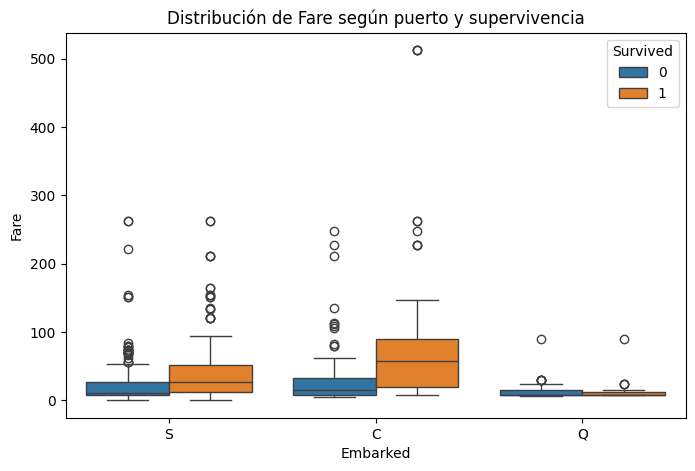

In [ ]:
# Distribución real de tarifas dentro de cada puerto y de supervivencia

plt.figure(figsize=(8,5))
sns.boxplot(data=titanic, x="Embarked", y="Fare", hue="Survived")
plt.title("Distribución de Fare según puerto y supervivencia")
plt.show()


##Análisis

La relación entre tarifa y supervivencia no es homogénea entre puertos. En Cherbourg y Southampton, los pasajeros que pagaron tarifas más altas tuvieron mayor probabilidad de sobrevivir. Mientras que en Queenstown esta diferencia es mucho menos marcada.

Con esto podemos análizar que su embarque y por supuesto lo que pagaban representaban diferentes accesos a recursos a la hora de evacuar y asi poder sobrevivir.

##Conclusión. Reflexión final

Lo que se me hizo más difícil de este análisis no fue la parte del código por que la verdad pedí ayuda, si no fue el saber que variables usar y poder combinar. Al principio uno quiere probar muchas cosas, pero el reto real está en pensar qué vale la pena investigar y cómo interpretar lo que aparece sin sacar conclusiones rápidas. Y ya despúes ahora si análizar esas gráfics y saber lo que nos estan dicendo en el contexto del problema.

Aprendí que el análisis exploratorio involucra todo desde observar, cuestionar, hasta buscar patrones con lógica. También entendí que los datos faltantes y las diferencias entre grupos pueden decir mucho si se analizan bien.